In [1]:
# 코랩 환경 기본 설치
!pip install nltk scikit-learn scipy pandas numpy matplotlib seaborn

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
from nltk import sent_tokenize
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')

text_sample = 'The Matrix is everywhere its all around us, here even in this room. \
You can see it out your window or on your television. \
You feel it when you go to work, or go to church or pay your taxes.'

sentences = sent_tokenize(text=text_sample)

print(type(sentences), len(sentences))
print(sentences)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


<class 'list'> 3
['The Matrix is everywhere its all around us, here even in this room.', 'You can see it out your window or on your television.', 'You feel it when you go to work, or go to church or pay your taxes.']


In [4]:
from nltk import word_tokenize

sentence = "The Matrix is everywhere its all around us, here even in this room."
words = word_tokenize(sentence)

print(type(words), len(words))
print(words)

<class 'list'> 15
['The', 'Matrix', 'is', 'everywhere', 'its', 'all', 'around', 'us', ',', 'here', 'even', 'in', 'this', 'room', '.']


In [5]:
from nltk import word_tokenize, sent_tokenize

def tokenize_text(text):
    sentences = sent_tokenize(text)
    word_tokens = [word_tokenize(sentence) for sentence in sentences]
    return word_tokens

word_tokens = tokenize_text(text_sample)
print(type(word_tokens), len(word_tokens))
print(word_tokens)

<class 'list'> 3
[['The', 'Matrix', 'is', 'everywhere', 'its', 'all', 'around', 'us', ',', 'here', 'even', 'in', 'this', 'room', '.'], ['You', 'can', 'see', 'it', 'out', 'your', 'window', 'or', 'on', 'your', 'television', '.'], ['You', 'feel', 'it', 'when', 'you', 'go', 'to', 'work', ',', 'or', 'go', 'to', 'church', 'or', 'pay', 'your', 'taxes', '.']]


In [6]:
import nltk
nltk.download('stopwords')

print('영어 stop words 개수:', len(nltk.corpus.stopwords.words('english')))
print(nltk.corpus.stopwords.words('english')[:20])

영어 stop words 개수: 198
['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been']


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [7]:
stopwords = nltk.corpus.stopwords.words('english')
all_tokens = []

for sentence in word_tokens:
    filtered_words = []
    for word in sentence:
        word = word.lower()
        if word not in stopwords:
            filtered_words.append(word)
    all_tokens.append(filtered_words)

print(all_tokens)

[['matrix', 'everywhere', 'around', 'us', ',', 'even', 'room', '.'], ['see', 'window', 'television', '.'], ['feel', 'go', 'work', ',', 'go', 'church', 'pay', 'taxes', '.']]


In [8]:
from nltk.stem import LancasterStemmer

stemmer = LancasterStemmer()

print(stemmer.stem('working'), stemmer.stem('works'), stemmer.stem('worked'))
print(stemmer.stem('amusing'), stemmer.stem('amuses'), stemmer.stem('amused'))
print(stemmer.stem('happier'), stemmer.stem('happiest'))
print(stemmer.stem('fancier'), stemmer.stem('fanciest'))

work work work
amus amus amus
happy happiest
fant fanciest


In [9]:
from nltk.stem import WordNetLemmatizer
import nltk

nltk.download('wordnet')

lemma = WordNetLemmatizer()

print(lemma.lemmatize('amusing', 'v'), lemma.lemmatize('amuses', 'v'), lemma.lemmatize('amused', 'v'))
print(lemma.lemmatize('happier', 'a'), lemma.lemmatize('happiest', 'a'))
print(lemma.lemmatize('fancier', 'a'), lemma.lemmatize('fanciest', 'a'))

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


amuse amuse amuse
happy happy
fancy fancy


In [10]:
import numpy as np
from scipy import sparse

dense = np.array([[3, 0, 1], [0, 2, 0]])

data = np.array([3, 1, 2])
row_pos = np.array([0, 0, 1])
col_pos = np.array([0, 2, 1])

sparse_coo = sparse.coo_matrix((data, (row_pos, col_pos)))
print(sparse_coo.toarray())

[[3 0 1]
 [0 2 0]]


In [11]:
dense2 = np.array([[0, 0, 1, 0, 0, 5],
                   [1, 4, 0, 3, 2, 5],
                   [0, 6, 0, 3, 0, 0],
                   [2, 0, 0, 0, 0, 0],
                   [0, 0, 0, 7, 0, 8],
                   [1, 0, 0, 0, 0, 0]])

data2    = np.array([1, 5, 1, 4, 3, 2, 5, 6, 3, 2, 7, 8, 1])
row_pos  = np.array([0, 0, 1, 1, 1, 1, 1, 2, 2, 3, 4, 4, 5])
col_pos  = np.array([2, 5, 0, 1, 3, 4, 5, 1, 3, 0, 3, 5, 0])

sparse_coo = sparse.coo_matrix((data2, (row_pos, col_pos)))

row_pos_ind = np.array([0, 2, 7, 9, 10, 12, 13])
sparse_csr  = sparse.csr_matrix((data2, col_pos, row_pos_ind))

print('COO 변환 확인')
print(sparse_coo.toarray())
print('CSR 변환 확인')
print(sparse_csr.toarray())

COO 변환 확인
[[0 0 1 0 0 5]
 [1 4 0 3 2 5]
 [0 6 0 3 0 0]
 [2 0 0 0 0 0]
 [0 0 0 7 0 8]
 [1 0 0 0 0 0]]
CSR 변환 확인
[[0 0 1 0 0 5]
 [1 4 0 3 2 5]
 [0 6 0 3 0 0]
 [2 0 0 0 0 0]
 [0 0 0 7 0 8]
 [1 0 0 0 0 0]]


In [12]:
# 밀집 행렬을 직접 입력해서 변환하는 방법
dense3 = np.array([[0, 0, 1, 0, 0, 5],
                   [1, 4, 0, 3, 2, 5],
                   [0, 6, 0, 3, 0, 0],
                   [2, 0, 0, 0, 0, 0],
                   [0, 0, 0, 7, 0, 8],
                   [1, 0, 0, 0, 0, 0]])

coo = sparse.coo_matrix(dense3)
csr = sparse.csr_matrix(dense3)
print('COO:\n', coo.toarray())
print('CSR:\n', csr.toarray())

COO:
 [[0 0 1 0 0 5]
 [1 4 0 3 2 5]
 [0 6 0 3 0 0]
 [2 0 0 0 0 0]
 [0 0 0 7 0 8]
 [1 0 0 0 0 0]]
CSR:
 [[0 0 1 0 0 5]
 [1 4 0 3 2 5]
 [0 6 0 3 0 0]
 [2 0 0 0 0 0]
 [0 0 0 7 0 8]
 [1 0 0 0 0 0]]


In [13]:
from sklearn.datasets import fetch_20newsgroups
import pandas as pd

news_data = fetch_20newsgroups(subset='all', random_state=156)

print(news_data.keys())
print('target 클래스의 값과 분포도\n', pd.Series(news_data.target).value_counts().sort_index())
print('target 클래스의 이름들\n', news_data.target_names)
print(news_data.data[0])

dict_keys(['data', 'filenames', 'target_names', 'target', 'DESCR'])
target 클래스의 값과 분포도
 0     799
1     973
2     985
3     982
4     963
5     988
6     975
7     990
8     996
9     994
10    999
11    991
12    984
13    990
14    987
15    997
16    910
17    940
18    775
19    628
Name: count, dtype: int64
target 클래스의 이름들
 ['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']
From: egreen@east.sun.com (Ed Green - Pixel Cruncher)
Subject: Re: Observation re: helmets
Organization: Sun Microsystems, RTP, NC
Lines: 21
Distribution: world
Reply-To: egreen@east.sun.com
NNTP-Posting-Host: laser.east.sun.com

In article 211353@mavenry.altcit.eskimo.com, 

In [14]:
train_news = fetch_20newsgroups(subset='train',
                                remove=('headers', 'footers', 'quotes'),
                                random_state=156)
X_train = train_news.data
y_train = train_news.target

test_news = fetch_20newsgroups(subset='test',
                               remove=('headers', 'footers', 'quotes'),
                               random_state=156)
X_test = test_news.data
y_test = test_news.target

print('학습 데이터 크기 {0}, 테스트 데이터 크기 {1}'.format(len(X_train), len(X_test)))

학습 데이터 크기 11314, 테스트 데이터 크기 7532


In [15]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

cnt_vect = CountVectorizer()
cnt_vect.fit(X_train)
X_train_cnt_vect = cnt_vect.transform(X_train)
X_test_cnt_vect  = cnt_vect.transform(X_test)

print('학습 데이터 CountVectorizer Shape:', X_train_cnt_vect.shape)

lr_clf = LogisticRegression(solver='liblinear')
lr_clf.fit(X_train_cnt_vect, y_train)
pred = lr_clf.predict(X_test_cnt_vect)

print('CountVectorized Logistic Regression 예측 정확도: {0:.3f}'.format(accuracy_score(y_test, pred)))

학습 데이터 CountVectorizer Shape: (11314, 101631)
CountVectorized Logistic Regression 예측 정확도: 0.617


In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vect = TfidfVectorizer()
tfidf_vect.fit(X_train)
X_train_tfidf_vect = tfidf_vect.transform(X_train)
X_test_tfidf_vect  = tfidf_vect.transform(X_test)

lr_clf = LogisticRegression(solver='liblinear')
lr_clf.fit(X_train_tfidf_vect, y_train)
pred = lr_clf.predict(X_test_tfidf_vect)

print('TF-IDF Logistic Regression 예측 정확도: {0:.3f}'.format(accuracy_score(y_test, pred)))

TF-IDF Logistic Regression 예측 정확도: 0.678


In [17]:
tfidf_vect = TfidfVectorizer(stop_words='english', ngram_range=(1, 2), max_df=300)
tfidf_vect.fit(X_train)
X_train_tfidf_vect = tfidf_vect.transform(X_train)
X_test_tfidf_vect  = tfidf_vect.transform(X_test)

lr_clf = LogisticRegression(solver='liblinear')
lr_clf.fit(X_train_tfidf_vect, y_train)
pred = lr_clf.predict(X_test_tfidf_vect)

print('TF-IDF Vectorized Logistic Regression 예측 정확도: {0:.3f}'.format(accuracy_score(y_test, pred)))

TF-IDF Vectorized Logistic Regression 예측 정확도: 0.690


In [18]:
from sklearn.model_selection import GridSearchCV

params = {'C': [0.01, 0.1, 1, 5, 10]}
grid_cv_lr = GridSearchCV(lr_clf, param_grid=params, cv=3, scoring='accuracy', verbose=1)
grid_cv_lr.fit(X_train_tfidf_vect, y_train)

print('Logistic Regression best C parameter:', grid_cv_lr.best_params_)

pred = grid_cv_lr.predict(X_test_tfidf_vect)
print('TF-IDF Vectorized Logistic Regression 예측 정확도: {0:.3f}'.format(accuracy_score(y_test, pred)))

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Logistic Regression best C parameter: {'C': 10}
TF-IDF Vectorized Logistic Regression 예측 정확도: 0.704


In [19]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('tfidf_vect', TfidfVectorizer(stop_words='english', ngram_range=(1, 2), max_df=300)),
    ('lr_clf',     LogisticRegression(solver='liblinear', C=10))
])

pipeline.fit(X_train, y_train)
pred = pipeline.predict(X_test)

print('Pipeline Logistic Regression 예측 정확도: {0:.3f}'.format(accuracy_score(y_test, pred)))

Pipeline Logistic Regression 예측 정확도: 0.704


In [6]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

# Imports for data loading
from sklearn.datasets import fetch_20newsgroups
import pandas as pd

# Load and split data
train_news = fetch_20newsgroups(subset='train',
                                remove=('headers', 'footers', 'quotes'),
                                random_state=156)
X_train = train_news.data
y_train = train_news.target

test_news = fetch_20newsgroups(subset='test',
                               remove=('headers', 'footers', 'quotes'),
                               random_state=156)
X_test = test_news.data
y_test = test_news.target


pipeline = Pipeline([
    ('tfidf_vect', TfidfVectorizer(stop_words='english')),
    ('lr_clf',     LogisticRegression())
])

params = {
    'tfidf_vect__ngram_range': [(1, 1), (1, 2)], # Reduced ngram_range
    'tfidf_vect__max_df':      [100, 300],      # Reduced max_df options
    'lr_clf__C':               [1, 5, 10]
}

grid_cv_pipe = GridSearchCV(pipeline, param_grid=params, cv=3, scoring='accuracy', verbose=1, n_jobs=1) # Changed n_jobs to 1
grid_cv_pipe.fit(X_train, y_train)

print(grid_cv_pipe.best_params_, grid_cv_pipe.best_score_)

pred = grid_cv_pipe.predict(X_test)
print('Pipeline + GridSearchCV 예측 정확도: {0:.3f}'.format(accuracy_score(y_test, pred)))

Fitting 3 folds for each of 12 candidates, totalling 36 fits
{'lr_clf__C': 10, 'tfidf_vect__max_df': 300, 'tfidf_vect__ngram_range': (1, 2)} 0.7533152393023013
Pipeline + GridSearchCV 예측 정확도: 0.701


In [7]:
import pandas as pd
import re

review_df = pd.read_csv('labeledTrainData.tsv', header=0, sep='\t', quoting=3)
review_df.head(3)

,id,sentiment,review
0,"""5814_8""",1,"""With all this stuff going down at the moment ..."
1,"""2381_9""",1,"""\""The Classic War of the Worlds\"" by Timothy ..."
2,"""7759_3""",0,"""The film starts with a manager (Nicholas Bell..."


In [8]:
# 전처리: <br /> 태그 제거, 영문자 외 제거
review_df['review'] = review_df['review'].str.replace('<br />', ' ', regex=False)
review_df['review'] = review_df['review'].apply(lambda x: re.sub(r'[^a-zA-Z]', ' ', x))

print(review_df['review'][0][:300])

 With all this stuff going down at the moment with MJ i ve started listening to his music  watching the odd documentary here and there  watched The Wiz and watched Moonwalker again  Maybe i just want to get a certain insight into this guy who i thought was really cool in the eighties just to maybe m


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

class_df   = review_df['sentiment']
feature_df = review_df.drop(['id', 'sentiment'], axis=1, inplace=False)

X_train, X_test, y_train, y_test = train_test_split(
    feature_df, class_df, test_size=0.3, random_state=156)

print(X_train.shape, X_test.shape)

(17500, 1) (7500, 1)


In [10]:
# CountVectorizer 기반
pipeline = Pipeline([
    ('cnt_vect', CountVectorizer(stop_words='english', ngram_range=(1, 2))),
    ('lr_clf',   LogisticRegression(solver='liblinear', C=10))
])

pipeline.fit(X_train['review'], y_train)
pred       = pipeline.predict(X_test['review'])
pred_probs = pipeline.predict_proba(X_test['review'])[:, 1]

print('예측 정확도: {0:.4f}, ROC-AUC: {1:.4f}'.format(
    accuracy_score(y_test, pred), roc_auc_score(y_test, pred_probs)))

예측 정확도: 0.8861, ROC-AUC: 0.9503


In [11]:
# TF-IDF 기반
pipeline = Pipeline([
    ('tfidf_vect', TfidfVectorizer(stop_words='english', ngram_range=(1, 2))),
    ('lr_clf',     LogisticRegression(solver='liblinear', C=10))
])

pipeline.fit(X_train['review'], y_train)
pred       = pipeline.predict(X_test['review'])
pred_probs = pipeline.predict_proba(X_test['review'])[:, 1]

print('예측 정확도: {0:.4f}, ROC-AUC: {1:.4f}'.format(
    accuracy_score(y_test, pred), roc_auc_score(y_test, pred_probs)))

예측 정확도: 0.8936, ROC-AUC: 0.9598


In [12]:
import nltk
nltk.download('all')   # 처음 한 번만, 시간 소요

from nltk.corpus import wordnet as wn

term = 'present'
synsets = wn.synsets(term)

print('synsets() 반환 type:', type(synsets))
print('synsets() 반환 값 개수:', len(synsets))
print('synsets() 반환 값:', synsets)

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_ru.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_rus to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |  

synsets() 반환 type: <class 'list'>
synsets() 반환 값 개수: 18
synsets() 반환 값: [Synset('present.n.01'), Synset('present.n.02'), Synset('present.n.03'), Synset('show.v.01'), Synset('present.v.02'), Synset('stage.v.01'), Synset('present.v.04'), Synset('present.v.05'), Synset('award.v.01'), Synset('give.v.08'), Synset('deliver.v.01'), Synset('introduce.v.01'), Synset('portray.v.04'), Synset('confront.v.03'), Synset('present.v.12'), Synset('salute.v.06'), Synset('present.a.01'), Synset('present.a.02')]


In [13]:
for synset in synsets:
    print('##### Synset name:', synset.name(), '#####')
    print('POS:', synset.lexname())
    print('Definition:', synset.definition())
    print('Lemmas:', synset.lemma_names())
    print()

##### Synset name: present.n.01 #####
POS: noun.time
Definition: the period of time that is happening now; any continuous stretch of time including the moment of speech
Lemmas: ['present', 'nowadays']

##### Synset name: present.n.02 #####
POS: noun.possession
Definition: something presented as a gift
Lemmas: ['present']

##### Synset name: present.n.03 #####
POS: noun.communication
Definition: a verb tense that expresses actions or states at the time of speaking
Lemmas: ['present', 'present_tense']

##### Synset name: show.v.01 #####
POS: verb.perception
Definition: give an exhibition of to an interested audience
Lemmas: ['show', 'demo', 'exhibit', 'present', 'demonstrate']

##### Synset name: present.v.02 #####
POS: verb.communication
Definition: bring forward and present to the mind
Lemmas: ['present', 'represent', 'lay_out']

##### Synset name: stage.v.01 #####
POS: verb.creation
Definition: perform (a play), especially on a stage
Lemmas: ['stage', 'present', 'represent']

##### Sy

In [14]:
# 단어 간 유사도
tree  = wn.synset('tree.n.01')
lion  = wn.synset('lion.n.01')
tiger = wn.synset('tiger.n.02')
cat   = wn.synset('cat.n.01')
dog   = wn.synset('dog.n.01')

entities      = [tree, lion, tiger, cat, dog]
entity_names  = [e.name().split('.')[0] for e in entities]
similarities  = []

for entity in entities:
    similarity = [round(entity.path_similarity(comp), 2) for comp in entities]
    similarities.append(similarity)

import pandas as pd
similarity_df = pd.DataFrame(similarities, columns=entity_names, index=entity_names)
print(similarity_df)

       tree  lion  tiger   cat   dog
tree   1.00  0.07   0.07  0.08  0.12
lion   0.07  1.00   0.33  0.25  0.17
tiger  0.07  0.33   1.00  0.25  0.17
cat    0.08  0.25   0.25  1.00  0.20
dog    0.12  0.17   0.17  0.20  1.00


In [15]:
from nltk.corpus import sentiwordnet as swn

senti_synsets = list(swn.senti_synsets('slow'))
print('반환 type:', type(senti_synsets))
print('반환 값 개수:', len(senti_synsets))
print('반환 값:', senti_synsets)

반환 type: <class 'list'>
반환 값 개수: 11
반환 값: [SentiSynset('decelerate.v.01'), SentiSynset('slow.v.02'), SentiSynset('slow.v.03'), SentiSynset('slow.a.01'), SentiSynset('slow.a.02'), SentiSynset('dense.s.04'), SentiSynset('slow.a.04'), SentiSynset('boring.s.01'), SentiSynset('dull.s.08'), SentiSynset('slowly.r.01'), SentiSynset('behind.r.03')]


In [16]:
father   = swn.senti_synset('father.n.01')
print('father 긍정감성 지수:', father.pos_score())
print('father 부정감성 지수:', father.neg_score())
print('father 객관성 지수:', father.obj_score())

fabulous = swn.senti_synset('fabulous.a.01')
print('fabulous 긍정감성 지수:', fabulous.pos_score())
print('fabulous 부정감성 지수:', fabulous.neg_score())

father 긍정감성 지수: 0.0
father 부정감성 지수: 0.0
father 객관성 지수: 1.0
fabulous 긍정감성 지수: 0.875
fabulous 부정감성 지수: 0.125


In [17]:
from nltk.corpus import wordnet as wn

def penn_to_wn(tag):
    if tag.startswith('J'):
        return wn.ADJ
    elif tag.startswith('N'):
        return wn.NOUN
    elif tag.startswith('R'):
        return wn.ADV
    elif tag.startswith('V'):
        return wn.VERB
    return None

In [18]:
from nltk.stem import WordNetLemmatizer
from nltk.corpus import sentiwordnet as swn
from nltk import sent_tokenize, word_tokenize, pos_tag

def swn_polarity(text):
    sentiment    = 0.0
    tokens_count = 0
    lemmatizer   = WordNetLemmatizer()
    raw_sentences = sent_tokenize(text)

    for raw_sentence in raw_sentences:
        tagged_sentence = pos_tag(word_tokenize(raw_sentence))
        for word, tag in tagged_sentence:
            wn_tag = penn_to_wn(tag)
            if wn_tag not in (wn.NOUN, wn.ADJ, wn.ADV):
                continue
            lemma = lemmatizer.lemmatize(word, pos=wn_tag)
            if not lemma:
                continue
            synsets = wn.synsets(lemma, pos=wn_tag)
            if not synsets:
                continue
            synset     = synsets[0]
            swn_synset = swn.senti_synset(synset.name())
            sentiment += (swn_synset.pos_score() - swn_synset.neg_score())
            tokens_count += 1

    if not tokens_count:
        return 0
    return 1 if sentiment >= 0 else 0

In [19]:
# review_df 재사용 (Step 4에서 이어짐)
review_df['preds'] = review_df['review'].apply(lambda x: swn_polarity(x))

from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import numpy as np

y_target = review_df['sentiment'].values
preds    = review_df['preds'].values

print(confusion_matrix(y_target, preds))
print('정확도:', np.round(accuracy_score(y_target, preds), 4))
print('정밀도:', np.round(precision_score(y_target, preds), 4))
print('재현율:', np.round(recall_score(y_target, preds), 4))

[[7669 4831]
 [3635 8865]]
정확도: 0.6614
정밀도: 0.6473
재현율: 0.7092


In [20]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

senti_analyzer = SentimentIntensityAnalyzer()
senti_scores   = senti_analyzer.polarity_scores(review_df['review'][0])
print(senti_scores)

{'neg': 0.13, 'neu': 0.743, 'pos': 0.127, 'compound': -0.7943}


In [21]:
def vader_polarity(review, threshold=0.1):
    analyzer    = SentimentIntensityAnalyzer()
    scores      = analyzer.polarity_scores(review)
    agg_score   = scores['compound']
    return 1 if agg_score >= threshold else 0

review_df['vader_preds'] = review_df['review'].apply(lambda x: vader_polarity(x, 0.1))

y_target    = review_df['sentiment'].values
vader_preds = review_df['vader_preds'].values

print(confusion_matrix(y_target, vader_preds))
print('정확도:', np.round(accuracy_score(y_target, vader_preds), 4))
print('정밀도:', np.round(precision_score(y_target, vader_preds), 4))
print('재현율:', np.round(recall_score(y_target, vader_preds), 4))

[[ 6747  5753]
 [ 1858 10642]]
정확도: 0.6956
정밀도: 0.6491
재현율: 0.8514


In [22]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

cats = ['rec.motorcycles', 'rec.sport.baseball', 'comp.graphics', 'comp.windows.x',
        'talk.politics.mideast', 'soc.religion.christian', 'sci.electronics', 'sci.med']

news_df = fetch_20newsgroups(subset='all',
                             remove=('headers', 'footers', 'quotes'),
                             categories=cats,
                             random_state=0)

count_vect = CountVectorizer(max_df=0.95, max_features=1000,
                             min_df=2, stop_words='english',
                             ngram_range=(1, 2))
feat_vect = count_vect.fit_transform(news_df.data)
print('CountVectorizer Shape:', feat_vect.shape)

CountVectorizer Shape: (7862, 1000)


In [23]:
lda = LatentDirichletAllocation(n_components=8, random_state=0)
lda.fit(feat_vect)

print(lda.components_.shape)

(8, 1000)


In [24]:
def display_topics(model, feature_names, no_top_words):
    for topic_index, topic in enumerate(model.components_):
        print('Topic #', topic_index)
        topic_word_indexes = topic.argsort()[::-1]
        top_indexes        = topic_word_indexes[:no_top_words]
        feature_concat     = ' '.join([feature_names[i] for i in top_indexes])
        print(feature_concat)
        print()

feature_names = count_vect.get_feature_names_out()   # sklearn 최신버전
display_topics(lda, feature_names, 15)

Topic # 0
10 year medical health 1993 20 12 disease cancer team patients research number new 11

Topic # 1
don just like know think good time ve does way really people want ll right

Topic # 2
image file jpeg output program gif images format files color entry use bit 03 02

Topic # 3
armenian armenians turkish people said turkey armenia government genocide turks muslim russian greek azerbaijan killed

Topic # 4
israel jews dos jewish israeli dos dos arab state people arabs palestinian adl ed anti peace

Topic # 5
edu com available graphics ftp window use mail data motif software version pub information server

Topic # 6
god people jesus church believe say christ does christian think christians did know bible man

Topic # 7
thanks use using does help like display need problem know server screen windows window program



In [25]:
# UCI Opinion Review 데이터셋 다운로드
!wget -q https://archive.ics.uci.edu/ml/machine-learning-databases/00205/OpinosisDataset1.0_0.zip
!unzip -q OpinosisDataset1.0_0.zip

unzip:  cannot find or open OpinosisDataset1.0_0.zip, OpinosisDataset1.0_0.zip.zip or OpinosisDataset1.0_0.zip.ZIP.


In [26]:
import pandas as pd
import glob, os

path = './OpinosisDataset1.0/OpinosisDataset1.0/topics'
all_files = glob.glob(os.path.join(path, '*.data'))

filename_list = []
opinion_text  = []

for file_ in all_files:
    df       = pd.read_table(file_, index_col=None, header=0, encoding='latin1')
    filename = os.path.basename(file_).split('.')[0]
    filename_list.append(filename)
    opinion_text.append(df.to_string())

document_df = pd.DataFrame({'filename': filename_list, 'opinion_text': opinion_text})
pd.set_option('display.max_colwidth', 700)
document_df.head()

,filename,opinion_text


In [27]:
from nltk.stem import WordNetLemmatizer
from nltk import word_tokenize, pos_tag
from nltk.corpus import stopwords
import nltk

nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

def penn_to_wn(tag):
    if tag.startswith('J'):
        return 'a'
    elif tag.startswith('N'):
        return 'n'
    elif tag.startswith('R'):
        return 'r'
    elif tag.startswith('V'):
        return 'v'
    return None

lemmatizer = WordNetLemmatizer()
stop_words = stopwords.words('english')

def LemNormalize(text):
    tokens   = word_tokenize(text.lower())
    tagged   = pos_tag(tokens)
    result   = []
    for word, tag in tagged:
        wn_tag = penn_to_wn(tag)
        if word in stop_words or not word.isalpha():
            continue
        if wn_tag:
            lemma = lemmatizer.lemmatize(word, pos=wn_tag)
        else:
            lemma = lemmatizer.lemmatize(word)
        result.append(lemma)
    return result

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


In [35]:
import glob, os, urllib.request, zipfile
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Dataset download and extraction
def download_and_extract():
    url = 'https://github.com/kavgan/opinosis-summarization/raw/master/OpinosisDataset1.0_0.zip'
    zip_name = 'OpinosisDataset1.0_0.zip'

    if not os.path.exists('./OpinosisDataset1.0_0'):
        print('Downloading dataset from GitHub...')
        try:
            urllib.request.urlretrieve(url, zip_name)
            with zipfile.ZipFile(zip_name, 'r') as zip_ref:
                zip_ref.extractall('.')
            print('Extraction complete.')
        except Exception as e:
            print(f'Download or Extraction failed: {e}')

download_and_extract()

# 2. Data Loading
# The extraction might create a path like ./OpinosisDataset1.0_0/OpinosisDataset1.0/topics
# We use a recursive glob to find the files regardless of the nesting
all_files = glob.glob('./**/topics/*.data', recursive=True)

filename_list = []
opinion_text  = []

for file_ in all_files:
    df = pd.read_table(file_, index_col=None, header=0, encoding='latin1')
    filename = os.path.basename(file_).split('.')[0]
    filename_list.append(filename)
    opinion_text.append(df.to_string())

document_df = pd.DataFrame({'filename': filename_list, 'opinion_text': opinion_text})

# 3. TF-IDF Transformation
if not document_df.empty:
    tfidf_vect = TfidfVectorizer(tokenizer=LemNormalize, stop_words='english',
                                 ngram_range=(1, 2), min_df=0.05, max_df=0.85)
    feature_vect = tfidf_vect.fit_transform(document_df['opinion_text'])
    print('Document count:', len(document_df))
    print('feature_vect shape:', feature_vect.shape)
else:
    print('Data not loaded. Please check the directory structure.')

Extraction complete.


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['make', 'u'] not in stop_words.
  warnings.warn(


Document count: 51
feature_vect shape: (51, 3875)


In [36]:
from sklearn.cluster import KMeans

km_cluster = KMeans(n_clusters=5, max_iter=10000, random_state=0)
km_cluster.fit(feature_vect)

cluster_label   = km_cluster.labels_
cluster_centers = km_cluster.cluster_centers_

document_df['cluster_label'] = cluster_label
document_df.head()

,filename,opinion_text,cluster_label
0,speed_garmin_nuvi_255W_gps,Another feature on the 255w is a display of the posted speed limit on the road which you are currently on right above your current displayed speed .\n0 I found myself not even looking at my car speedometer as I could easily see my current speed and the speed limit of my route at a glance .\n1 ...,1
1,display_garmin_nuvi_255W_gps,"3 quot widescreen display was a bonus .\n0 This made for smoother graphics on the 255w of the vehicle moving along displayed roads, where the 750's display was more of a jerky movement .\n1 ...",1
2,speed_windows7,"Windows 7 is quite simply faster, more stable, boots faster, goes to sleep faster, comes back from sleep faster, manages your files better and on top of that it's beautiful to look at and easy to use .\n0 , faster about 20% to 30% faster at running applications than my Vista , seriously\n1 ...",1
3,location_bestwestern_hotel_sfo,"Good Value good location , ideal choice .\n0 Great Location , Nice Rooms , Helpless Concierge\n1 ...",4
4,service_holiday_inn_london,"not customer, oriented hotelvery low service levelboor reception\n0 The room was quiet, clean, the bed and pillows were comfortable, and the serv...",0


In [37]:
# 클러스터별 확인
for i in range(5):
    print(f'\n===== Cluster #{i} =====')
    print(document_df[document_df['cluster_label'] == i].sort_values('filename')['filename'].values)


===== Cluster #0 =====
['bathroom_bestwestern_hotel_sfo' 'free_bestwestern_hotel_sfo'
 'room_holiday_inn_london' 'rooms_bestwestern_hotel_sfo'
 'rooms_swissotel_chicago' 'service_bestwestern_hotel_sfo'
 'service_holiday_inn_london' 'service_swissotel_hotel_chicago'
 'staff_bestwestern_hotel_sfo' 'staff_swissotel_chicago']

===== Cluster #1 =====
['accuracy_garmin_nuvi_255W_gps' 'battery-life_amazon_kindle'
 'battery-life_ipod_nano_8gb' 'battery-life_netbook_1005ha'
 'buttons_amazon_kindle' 'directions_garmin_nuvi_255W_gps'
 'display_garmin_nuvi_255W_gps' 'eyesight-issues_amazon_kindle'
 'features_windows7' 'fonts_amazon_kindle' 'keyboard_netbook_1005ha'
 'navigation_amazon_kindle' 'performance_netbook_1005ha'
 'satellite_garmin_nuvi_255W_gps' 'screen_garmin_nuvi_255W_gps'
 'screen_ipod_nano_8gb' 'screen_netbook_1005ha' 'size_asus_netbook_1005ha'
 'sound_ipod_nano_8gb' 'speed_garmin_nuvi_255W_gps' 'speed_windows7'
 'updates_garmin_nuvi_255W_gps' 'video_ipod_nano_8gb'
 'voice_garmin_nuv

In [38]:
# 클러스터 3개로 재군집화
km_cluster = KMeans(n_clusters=3, max_iter=10000, random_state=0)
km_cluster.fit(feature_vect)

document_df['cluster_label'] = km_cluster.labels_

for i in range(3):
    print(f'\n===== Cluster #{i} =====')
    print(document_df[document_df['cluster_label'] == i].sort_values('filename')['filename'].values)


===== Cluster #0 =====
['bathroom_bestwestern_hotel_sfo' 'food_holiday_inn_london'
 'food_swissotel_chicago' 'free_bestwestern_hotel_sfo'
 'location_bestwestern_hotel_sfo' 'location_holiday_inn_london'
 'parking_bestwestern_hotel_sfo' 'price_amazon_kindle'
 'price_holiday_inn_london' 'room_holiday_inn_london'
 'rooms_bestwestern_hotel_sfo' 'rooms_swissotel_chicago'
 'service_bestwestern_hotel_sfo' 'service_holiday_inn_london'
 'service_swissotel_hotel_chicago' 'staff_bestwestern_hotel_sfo'
 'staff_swissotel_chicago']

===== Cluster #1 =====
['accuracy_garmin_nuvi_255W_gps' 'battery-life_amazon_kindle'
 'battery-life_ipod_nano_8gb' 'battery-life_netbook_1005ha'
 'buttons_amazon_kindle' 'directions_garmin_nuvi_255W_gps'
 'display_garmin_nuvi_255W_gps' 'eyesight-issues_amazon_kindle'
 'features_windows7' 'fonts_amazon_kindle' 'keyboard_netbook_1005ha'
 'navigation_amazon_kindle' 'performance_netbook_1005ha'
 'satellite_garmin_nuvi_255W_gps' 'screen_garmin_nuvi_255W_gps'
 'screen_ipod_nan

In [39]:
def get_cluster_details(cluster_model, cluster_data, feature_names,
                        clusters_num, top_n_features=10):
    cluster_details = {}
    centroid_feature_ordered_ind = cluster_model.cluster_centers_.argsort()[:, ::-1]

    for cluster_num in range(clusters_num):
        cluster_details[cluster_num] = {}
        cluster_details[cluster_num]['cluster'] = cluster_num

        top_feature_indexes = centroid_feature_ordered_ind[cluster_num, :top_n_features]
        top_features        = [feature_names[ind] for ind in top_feature_indexes]
        top_feature_values  = cluster_model.cluster_centers_[cluster_num, top_feature_indexes].tolist()

        cluster_details[cluster_num]['top_features']       = top_features
        cluster_details[cluster_num]['top_features_value'] = top_feature_values

        filenames = cluster_data[cluster_data['cluster_label'] == cluster_num]['filename']
        cluster_details[cluster_num]['filenames'] = filenames.values.tolist()

    return cluster_details


def print_cluster_details(cluster_details):
    for cluster_num, cluster_detail in cluster_details.items():
        print(f'####### Cluster {cluster_num}')
        print('Top features:', cluster_detail['top_features'])
        print('Reviews 파일명:', cluster_detail['filenames'][:7])
        print('=' * 50)

In [40]:
feature_names   = tfidf_vect.get_feature_names_out()
cluster_details = get_cluster_details(cluster_model=km_cluster,
                                      cluster_data=document_df,
                                      feature_names=feature_names,
                                      clusters_num=3,
                                      top_n_features=10)
print_cluster_details(cluster_details)

####### Cluster 0
Top features: ['room', 'hotel', 'service', 'staff', 'food', 'location', 'price', 'bathroom', 'clean', 'parking']
Reviews 파일명: ['location_bestwestern_hotel_sfo', 'service_holiday_inn_london', 'staff_bestwestern_hotel_sfo', 'food_holiday_inn_london', 'rooms_bestwestern_hotel_sfo', 'bathroom_bestwestern_hotel_sfo', 'food_swissotel_chicago']
####### Cluster 1
Top features: ['screen', 'battery', 'battery life', 'keyboard', 'life', 'direction', 'size', 'video', 'feature', 'voice']
Reviews 파일명: ['speed_garmin_nuvi_255W_gps', 'display_garmin_nuvi_255W_gps', 'speed_windows7', 'screen_netbook_1005ha', 'voice_garmin_nuvi_255W_gps', 'eyesight-issues_amazon_kindle', 'screen_ipod_nano_8gb']
####### Cluster 2
Top features: ['interior', 'seat', 'mileage', 'comfortable', 'gas', 'gas mileage', 'transmission', 'car', 'performance', 'quality']
Reviews 파일명: ['quality_toyota_camry_2007', 'mileage_honda_accord_2008', 'performance_honda_accord_2008', 'transmission_toyota_camry_2007', 'interi

In [41]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

def cos_similarity(v1, v2):
    dot_product = np.dot(v1, v2)
    l2_norm     = np.sqrt(sum(np.square(v1))) * np.sqrt(sum(np.square(v2)))
    return dot_product / l2_norm

doc_list = [
    'if you take the blue pill, the story ends',
    'if you take the red pill, you stay in Wonderland',
    'if you take the red pill, I show you how deep the rabbit hole goes'
]

tfidf_vect_simple  = TfidfVectorizer()
feature_vect_simple = tfidf_vect_simple.fit_transform(doc_list)
print('Shape:', feature_vect_simple.shape)

Shape: (3, 18)


In [42]:
feature_vect_dense = feature_vect_simple.todense()

vect1 = np.array(feature_vect_dense[0]).reshape(-1,)
vect2 = np.array(feature_vect_dense[1]).reshape(-1,)
vect3 = np.array(feature_vect_dense[2]).reshape(-1,)

print('문장 1, 문장 2 Cosine 유사도: {0:.3f}'.format(cos_similarity(vect1, vect2)))
print('문장 1, 문장 3 Cosine 유사도: {0:.3f}'.format(cos_similarity(vect1, vect3)))
print('문장 2, 문장 3 Cosine 유사도: {0:.3f}'.format(cos_similarity(vect2, vect3)))

문장 1, 문장 2 Cosine 유사도: 0.402
문장 1, 문장 3 Cosine 유사도: 0.404
문장 2, 문장 3 Cosine 유사도: 0.456


In [43]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_simple_pair = cosine_similarity(feature_vect_simple[0], feature_vect_simple)
print(similarity_simple_pair)

# 자기 자신 제외
similarity_simple_pair = cosine_similarity(feature_vect_simple[0], feature_vect_simple[1:])
print(similarity_simple_pair)

# 전체 쌍
similarity_simple_pair = cosine_similarity(feature_vect_simple, feature_vect_simple)
print(similarity_simple_pair)
print('shape:', similarity_simple_pair.shape)

[[1.         0.40207758 0.40425045]]
[[0.40207758 0.40425045]]
[[1.         0.40207758 0.40425045]
 [0.40207758 1.         0.45647296]
 [0.40425045 0.45647296 1.        ]]
shape: (3, 3)


In [44]:
# Step 7의 km_cluster(3개), feature_vect, document_df 재사용

from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt

hotel_indexes      = document_df[document_df['cluster_label'] == 2].index
comparison_docname = document_df.iloc[hotel_indexes[0]]['filename']
print('비교 기준 문서명:', comparison_docname)

similarity_pair = cosine_similarity(feature_vect[hotel_indexes[0]], feature_vect[hotel_indexes])
print(similarity_pair)

비교 기준 문서명: quality_toyota_camry_2007
[[1.         0.09808529 0.18591214 0.11297808 0.1777384  0.14428046
  0.20268717 0.17510953 0.09826705 0.2162623 ]]


가장 유사도가 큰 파일명 및 유사도:
 filename      comfort_toyota_camry_2007
similarity                     0.216262
Name: 0, dtype: object


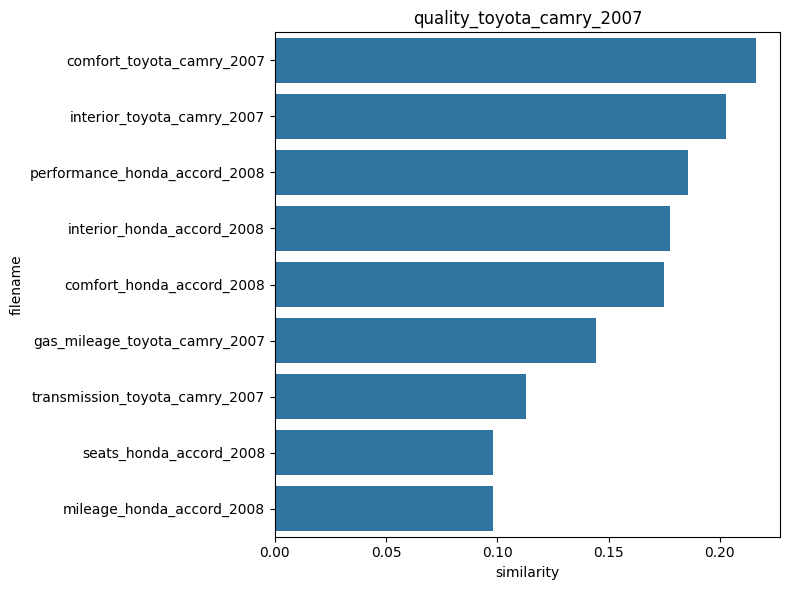

In [45]:
sorted_index         = similarity_pair.argsort()[:, ::-1]
sorted_index         = sorted_index[:, 1:]          # 자기 자신 제외

hotel_sorted_indexes = hotel_indexes[sorted_index.reshape(-1)]
hotel_1_sim_value    = np.sort(similarity_pair.reshape(-1))[::-1]
hotel_1_sim_value    = hotel_1_sim_value[1:]

hotel_1_sim_df             = pd.DataFrame()
hotel_1_sim_df['filename']  = document_df.iloc[hotel_sorted_indexes]['filename'].values
hotel_1_sim_df['similarity'] = hotel_1_sim_value

print('가장 유사도가 큰 파일명 및 유사도:\n', hotel_1_sim_df.iloc[0, :])

plt.figure(figsize=(8, 6))
sns.barplot(x='similarity', y='filename', data=hotel_1_sim_df)
plt.title(comparison_docname)
plt.tight_layout()
plt.show()